In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

INITIAL_FEATURES_PATH = PROJECT_ROOT / 'data' / 'normal_features'
TRAIN_PATH = INITIAL_FEATURES_PATH / 'train.parquet'
VAL_PATH = INITIAL_FEATURES_PATH / 'val.parquet'
TEST_PATH = INITIAL_FEATURES_PATH / 'test.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Using device: cuda


# KNN based Model - on initial features
By leveraging initial features, we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `RobustScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with initial features

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


## 2. Baseline Model

[KNN_baseline] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_baseline] Starting training...
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10370
           1     1.0000    1.0000    1.0000     11255

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



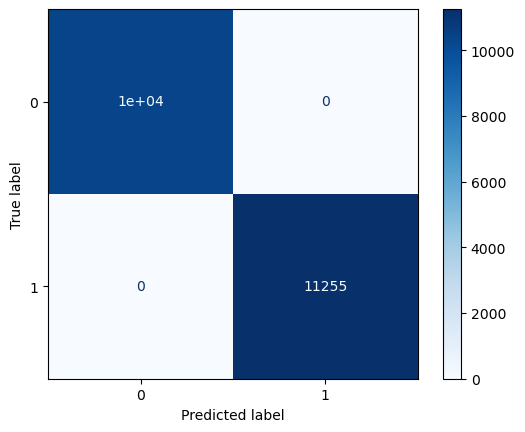

In [3]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline.train_pipeline(df_train, random_state=RANDOM_STATE)

The confusion matrix for the training set shows an accuracy of 100%. This indicates severe overfitting, most probably because the number of neighbors is set to 5, that is relatively small and it's evaluated on the same data it stored, ending in just memorizing the training set instead of generalize the predictions.

[KNN_baseline] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.5047
1    0.4953
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.5468    0.6111    0.5771      5047
           1     0.5498    0.4839    0.5148      4953

    accuracy                         0.5481     10000
   macro avg     0.5483    0.5475    0.5460     10000
weighted avg     0.5483    0.5481    0.5463     10000



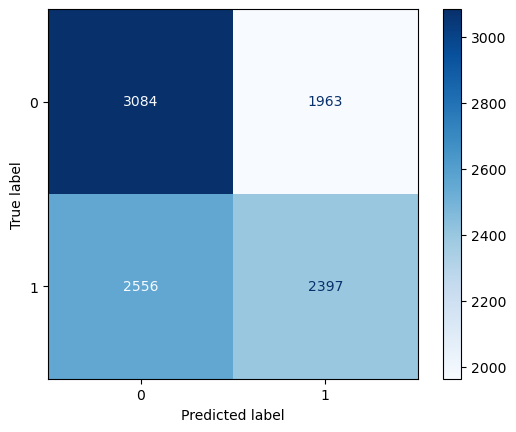

In [4]:
KNN_baseline.test_pipeline(df_test.sample(10000))

When evaluated on the unseen test data, the model's accuracy drops drastically to approximately 54.8%. The matrix shows a similar number of false positives and negatives across the true positives and negatives. This significant performance gap confirms that the baseline model failed to generalize to new data.

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [5]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

[KNN_initial] Grid Search...
[KNN_initial] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_initial] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 50000 samples...

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}

Optimal model ready: KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=15)
[KNN_initial] Train model with best params...
[KNN_initial] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_initial] Starting training...
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10438
           1     1.0000    1.0000    1.0000     11187

    accuracy                         1.0000     21625
   macro avg     1.0000    1.000

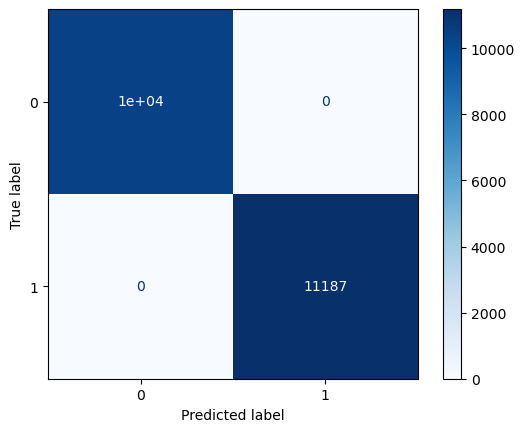

In [6]:
# tuning
KNN_initial = KNNModel("KNN_initial")
KNN_initial.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS)

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

[KNN_initial] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
1    0.5003
0    0.4997
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.5586    0.6452    0.5988      4997
           1     0.5807    0.4907    0.5319      5003

    accuracy                         0.5679     10000
   macro avg     0.5696    0.5679    0.5653     10000
weighted avg     0.5696    0.5679    0.5653     10000



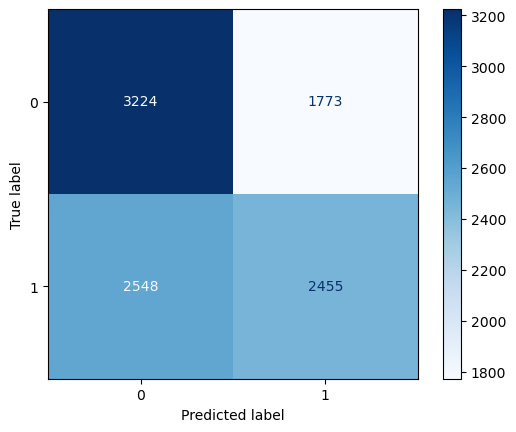

In [9]:
KNN_initial.test_pipeline(df_test.sample(10000))

After performing a Grid Search, the optimal number of neighbors increased to 15 using the Euclidean metric. This hypertuned model achieved a test accuracy of 56.79%, a slightly increase in performance respect to the baseline, but still the model keep confronting the problem of overfitting as showed in the hypertuned model for the train set.

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [8]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(KNN_initial, df_name='initial_features', 
                    model_name="Best_KNN_initial_based", 
                    relative_model_dir=MODEL_SAVE_PATH)